<a href="https://colab.research.google.com/github/ichristov/intermediate-fluid-mechanics/blob/main/extras/Slip_Flow_Channel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LEARNING OBJECTIVE

This notebook shows how to visualize Poiseuille in a nanochannel with slip at the bottom wall.

# PRELIMINARIES

[run the next cell to setup Python environment customizations and load packages]

In [25]:
# interactive plots setup
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

# ploting customizations
from matplotlib import pyplot as plt
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25}
plt.rcParams.update(params)
%matplotlib inline

# numerics
import numpy as np

# for Colab only: to save plots as files and download them
#from google.colab import files

## Credit

Initial version written by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University.

# PROBLEM STATEMENT

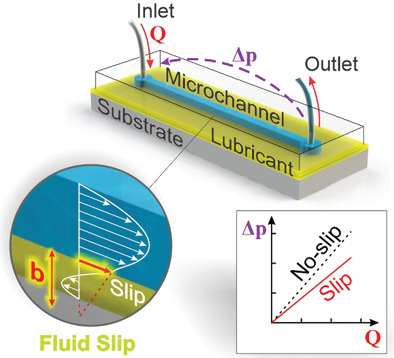

Figure from https://advanced.onlinelibrary.wiley.com/doi/full/10.1002/admi.202101641

The mean free path of H<sub>2</sub>O molecules (water) is $\lambda = 0.3$ nanometers (nm). It is generally estimated that the incompressible Navier&ndash;Stokes equations (and the continuum approximation that they are based upon) can still hold true at [Knudsen number](https://en.wikipedia.org/wiki/Knudsen_number) values as "large" as $Kn \approx 0.1$. The Knudsen number (recall discussion in Panton, Ch. 1) is defined as $Kn = \lambda/h$, where $h$ here is the height of the slot (channel). This means that iNS may hold for channel height $h$ as small as $\lambda/0.1 \approx 3$ nm!

However, in such flows, the fluid molecules might _not_ "stick" to the wall, and the no-slip boundary condition (BC) has to be replaced by Navier's (partial) slip BC. Thus, the goal of this problem is to solve for the pressure-driven flow in a 2D nanochannel with slip at the bottom wall.

(a) Starting with the incompressible Navier&ndash;Stokes equations and assuming no body forces, find the steady unidirectional velocity profile for plane Poiseuille flow with Navier (partial) slip. That is, assume $\underline{v} = (v_x(y),0,0)$ in a slot of height $h$ with a known axial pressure gradient $-dp/dx = \Delta p/L$, a stationary top wall at which the fluid satisfies no slip [$v_x(h) = 0$] and a stationary lower surface at which partial slip occurs [$v_x(0) = \ell_s \frac{d v_x}{dy}(0)$]. 

(b) Based on (a), derive an expression for the flow rate $Q$ across any vertical section of the channel as a function of the quantities presumed known/given. If you measured $Q$ in such an experiment with a known pressure drop in a slot of axial length $L$, how could you determine if partial slip was occurring?


# SOLUTION

## (a) velocity profile

For the given unidirectional flow profile, the incompressible Navier&ndash;Stokes equations simplify to
\begin{align*}
    0 &= -\frac{\partial p}{\partial x} + \mu \frac{\partial^2 v_x}{\partial y^2},\\
    0 &= -\frac{\partial p}{\partial y},\\
    0 &= -\frac{\partial p}{\partial z}.
\end{align*}
Thus, $p=p(x)$ only, $\partial p/\partial x = dp/dx - \Delta p/L$ is given, and ${\partial^2 v_x}/{\partial y^2} = d^2 v_x/dy^2$ since $v_x=v_x(y)$ only.

The appropriate boundary conditions (slip at the bottom wall, no slip at the top wall) are as given in the problem description,
$$ 
        v_x(0) = \ell_s \frac{dv_x}{dy}(0),\qquad v_x(h) = 0.
$$

From the $x$-momentum equation, we find, after one integration with respect to $y$ that
$$
    \frac{d v_x}{dy}(y) = -\frac{\Delta p}{\mu L} y + C_1,
$$
and after another that
$$ 
    v_x(y) = -\frac{\Delta p}{2\mu L} y^2 + C_1 y + C_2. 
$$
We can use these **two** expressions to evaluate the boundary conditions and find the integration constants.

From the 2nd boundary condition, we get 
$$ 
    -\frac{\Delta p}{2\mu L} + C_1 h + C_2 = 0 \quad\Rightarrow\quad C_2 = -\frac{h^2}{2\mu}\frac{dp}{dx} - C_1 h. 
$$
From the 1st boundary codinition, using the latter result for $C_2$, we get
$$  
    \frac{h^2\Delta p}{2\mu L} - C_1 h  = \ell_s C_1 \quad\Rightarrow\quad C_1 = \frac{h^2\Delta p}{2\mu(\ell_s+h)L}. 
$$

Putting all these results together, we obtain the steady unidirectional velocity profile:
$$
    v_x(y) = \frac{h^2\Delta p}{2\mu L} \left[\frac{\ell_s}{\ell_s+h} + \frac{y}{\ell_s+h} -\left(\frac{y}{h}\right)^2\right].
$$
We can easily verify that the plane Poiseuille flow profile (Panton's Section 7.4) from class is recovered in the limit $\ell_s \to 0$.


The dimensionless form of this solution is
$$
  \frac{v_x}{h^2\Delta p/(\mu L)} = v_x^*(y^*) = \frac{1}{2}\left[\frac{\ell_s/h}{\ell_s/h + 1} + \frac{y^*}{\ell_s/h + 1} - (y^*)^2\right],\qquad y^* = \frac{y}{h}
$$

The solution is characterized by a single dimensionless number $\ell_s/h$, the ratio of the slip length to the height of the nanochannel. We expect this number to be **small** and **positive** on physical grounds.

### visualizing the effect of slip

Let's use a [`quiver`](https://matplotlib.org/stable/gallery/images_contours_and_fields/quiver_simple_demo.html) plot to show the velocity arrows, and a regular line plot to show he envelope of the vectors.

In [26]:
def plot_func(ls_over_h):
  # y^* goes from 0 to 1
  y = np.linspace(0, 1)
  # v_x^* as defined above
  vx = (1/2)*(ls_over_h/(ls_over_h+1) + y/(ls_over_h+1) - y**2)

  fig, ax = plt.subplots(tight_layout=True)
  ax.set_ylabel('$y^* = y/h$')
  ax.set_ylim(0,1)
  ax.set_xlabel(r'$v_x^* = \frac{v_x}{h^2\Delta p/(\mu L)}$')

  # we have to be judicious with the xlim interval,
  # to make sure we can see the flow for all values of Po
  # allowed in the slider
  ax.set_xlim(-0.1,0.4)

  # skip every other data point (using "::2") to reduce number of arrows
  # plot arrows emanating only from the reference line, x-coord = 0
  ax.plot(vx, y, color='blue', linewidth=4)  
  ax.quiver(0*y[::2], y[::2],
            vx[::2], 0*vx[::2],
            scale=1., scale_units='xy', color='skyblue', zorder=2)
  
  ax.grid(alpha=0.5, linestyle='dotted')

  plt.show()

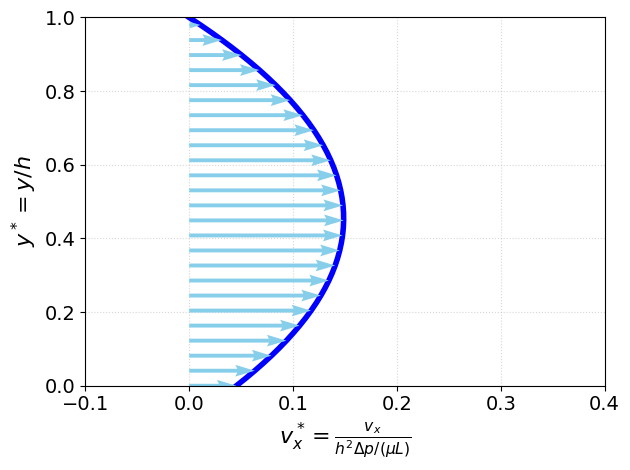

In [27]:
plot_func(0.1)

An [`interact`](https://ipywidgets.readthedocs.io/en/latest/examples/Using%20Interact.html) widget will let us vary $\ell_s/h$.

In [28]:
interact(plot_func, ls_over_h = widgets.FloatSlider(value=0.1,
                                                    min=0,
                                                    max=+1,
                                                    step=0.05,
                                                    description='ℓ_s/h'));

interactive(children=(FloatSlider(value=0.1, description='ℓ_s/h', max=1.0, step=0.05), Output()), _dom_classes…

## (b) flow rate

The flow rate computed across any vertical slice of the nanochannel is
\begin{align*}
    Q = \int_0^h v_x(y) \, dy &= \frac{h^2\Delta p}{2\mu L} \left[\frac{\ell_s}{\ell_s+h} y + \frac{y^2}{2(\ell_s+h)} -\frac{y^3}{3h^2}\right]_{0}^{h}\\
    &= \frac{h^2 \Delta p}{2\mu L} \left[\frac{\ell_sh}{\ell_s+h} + \frac{h^2}{2(\ell_s+h)} -\frac{h}{3}\right] \\
    &= \frac{h^3\Delta p}{12\mu L} \left[\frac{4\ell_s + h}{\ell_s+h} \right] \\
    &= \frac{h^3 \Delta p}{12 \mu L}\left[\frac{4\ell_s/h + 1}{\ell_s/h + 1}\right],
\end{align*}
or
$$
    \Delta p = 12\frac{\mu L}{h^3}Q.
$$

One way to determine if slip was occurring in this nanochannel is to plot $\Delta p$ (known) vs $Q$ (also known) and measure the slope. If the slope were $12\frac{\mu L}{h^3}$, then clearly we must have $\ell_s/h = 0$ (no slip). If a slope other than $12\frac{\mu L}{h^3}$ were measured, this would be suggestive of slip.

### visualizing the effect of slip

We plot $\Delta p$ vs $\mu L Q/h^3$ for different values of $\ell_s/h$ to see this in action, as in the featured image at the top of the notebook. The slope with slip should be reduced from $12$ by exactly the factor $\frac{\ell_s/h + 1}{4\ell_s/h + 1}$ calculated above.

In [74]:
def plot_func_dp(ls_over_h):
  factor = (ls_over_h+1)/(4*ls_over_h+1)

  # Delta p goes from 0 to 100 (kPa)
  dp = np.linspace(0, 100)
  # scaled flow rate as defined above
  QQ = (1/12)*(4*ls_over_h+1)/(ls_over_h+1)*dp

  fig, ax = plt.subplots(tight_layout=True)
  ax.set_xlabel(r'$\mu L Q /h^3$ (kPa)')
  ax.set_xlim(0,dp.max()/12) # pick a range that can show all curves well
  ax.set_ylabel(r'$\Delta p$ (kPa)')
  ax.set_ylim(dp.min(),dp.max())

  # flow rate with slip
  ax.plot(QQ, dp, color='red', linewidth=4, 
          label=rf'slip, $\mathrm{{slope}}=12\cdot{factor:.2f}$')  
  # flow rate with no slip for reference
  ax.plot(dp, 12*dp, color='black', linewidth=2, linestyle='dashed', 
          label=r'no slip, $\mathrm{slope}=12$')

  ax.legend(loc='upper left')

  ax.grid(alpha=0.5, linestyle='dotted')

  ax.set_aspect(1/12)

  plt.show()

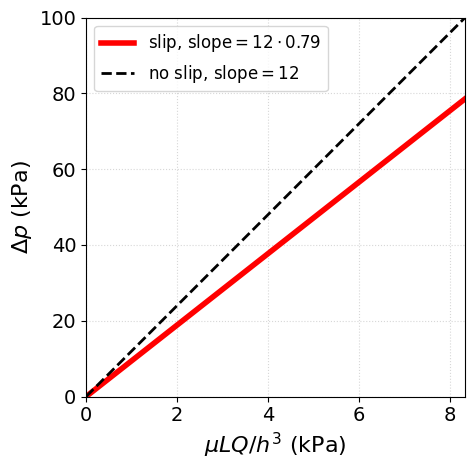

In [75]:
plot_func_dp(0.1)

An [`interact`](https://ipywidgets.readthedocs.io/en/latest/examples/Using%20Interact.html) widget will let us vary $\ell_s/h$.

In [76]:
interact(plot_func_dp, ls_over_h = widgets.FloatSlider(value=0.1,
                                                       min=0,
                                                       max=+1,
                                                       step=0.05,
                                                       description='ℓ_s/h'));

interactive(children=(FloatSlider(value=0.1, description='ℓ_s/h', max=1.0, step=0.05), Output()), _dom_classes…

### using dimensionless numbers

Working with dimensionless variables is better, so we can rephrase the latter creterion as whether the ratio $\frac{Q}{h^3\Delta p/(\mu L)}$ is $\frac{1}{12}$ or not. How much larger than $\frac{1}{12}$ it is depends on $\ell_s$ via the factor $\frac{4\ell_s/h + 1}{\ell_s/h + 1} = 1 + \frac{3\ell_s/h}{\ell_s/h + 1}>1$. 

Thus, the key observation is that the flow rate in a nanochannel with slip is larger than in the same nanochannel with no slip.

We can visualize the flow rate enhancement due to slip by plotting the ratio $\frac{Q}{h^3\Delta p/(\mu L)}$ vs the ratio $\frac{\ell_s}{h}$ and checking how much bigger than $\frac{1}{12} \approx 0.08333$ it is.

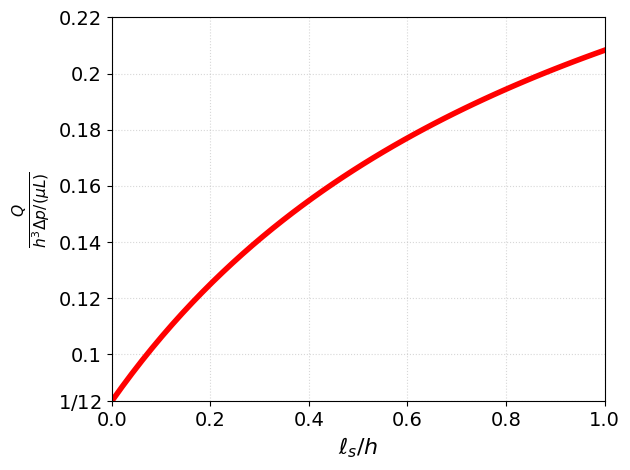

In [79]:
ls_over_h = np.linspace(0, 1)
qq = 1/12*(4*ls_over_h+1)/(ls_over_h+1)

fig, ax = plt.subplots(tight_layout=True)
ax.set_ylabel(r'$\frac{Q}{h^3\Delta p/(\mu L)}$')
ax.set_ylim(1/12, qq.max()*1.01)

# customize y-ticks to show 1/12 as a fraction
yticks = ax.get_yticks()
new_tick = 1/12
# delete any existing ticks below new_tick, which is the lowest value we want
yticks = yticks[yticks > new_tick]
# add 1/12 tick
yticks = np.append(yticks, new_tick)
yticks = np.sort(yticks)
ax.set_yticks(yticks)
# add 1/12 tick label
ax.set_yticklabels([str(np.round(y,3)) if ~np.isclose(y, new_tick) else '$1/12$' for y in yticks])

ax.set_xlabel(r'$\ell_s/h$')
ax.set_xlim(0,1)

ax.grid(alpha=0.5, linestyle='dotted')

ax.plot(ls_over_h, qq, color='red', linewidth=4)

plt.show()

## Further reading:

* C. Vega-S&aacute;nchez, C. Neto, "Pressure Drop Measurements in Microfluidic Devices: A Review on the Accurate Quantification of Interfacial Slip," _Adv. Mater. Interfaces_ **9** (2022) 2101641. https://doi.org/10.1002/admi.202101641